# Gaussian Mixture Model on PCA of TS space

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, cross_sec_lon, cross_sec_lon_prob

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [5]:
# Scale data
scaler = StandardScaler()
scaled_ST = scaler.fit_transform(df_ST[features])

In [6]:
# Use PCA to reduce dimensionality
pca = PCA(n_components=2)  # 2 principal components
X_pca = pca.fit_transform(scaled_ST)

In [7]:
# How much variance is explained by each component
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each component: {explained_variance}')

Explained variance by each component: [0.68395993 0.31604007]


In [8]:
# Four clusters for comparison of methods
n_clusters = 4

In [9]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_pca)

In [10]:
df_ST['gmm_label_4'] = labels

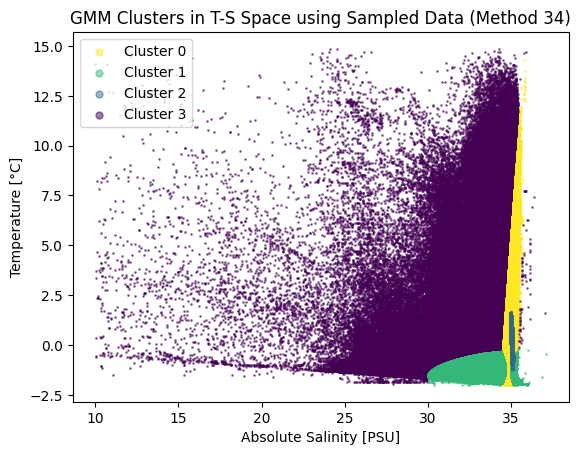

In [11]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_ST['gmm_label_4'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [12]:
# Sample geographically for better plotting
df_sampled_plot = df_ST.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters=4)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_again/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



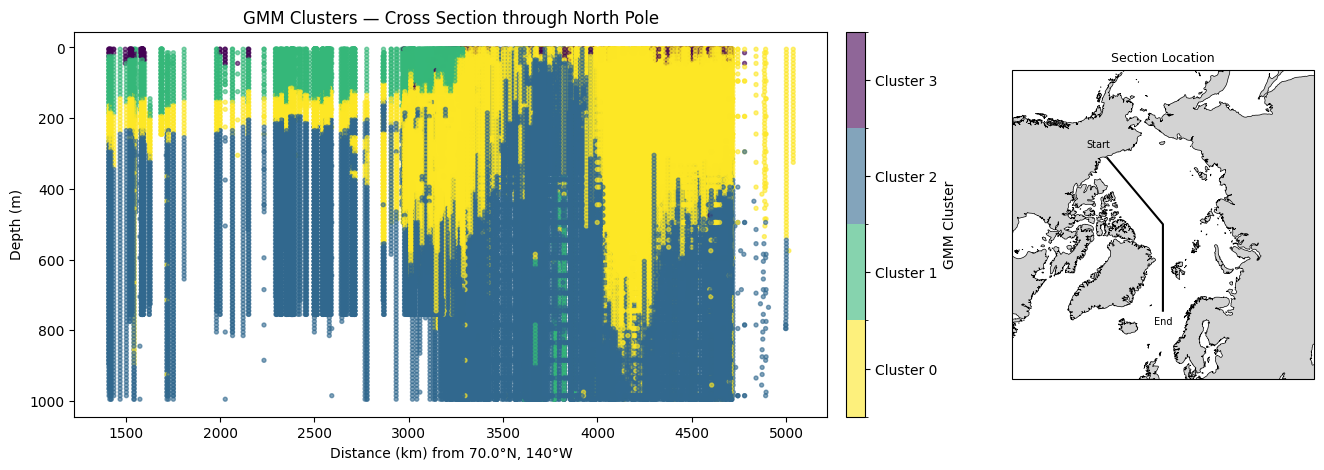

In [13]:
cross_sec_lon(df_ST, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [14]:
# Get probabilities for each cluster
for i in range(n_clusters):
    df_ST[f'prob_cluster_{i}'] = gmm.predict_proba(X_pca)[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_again/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



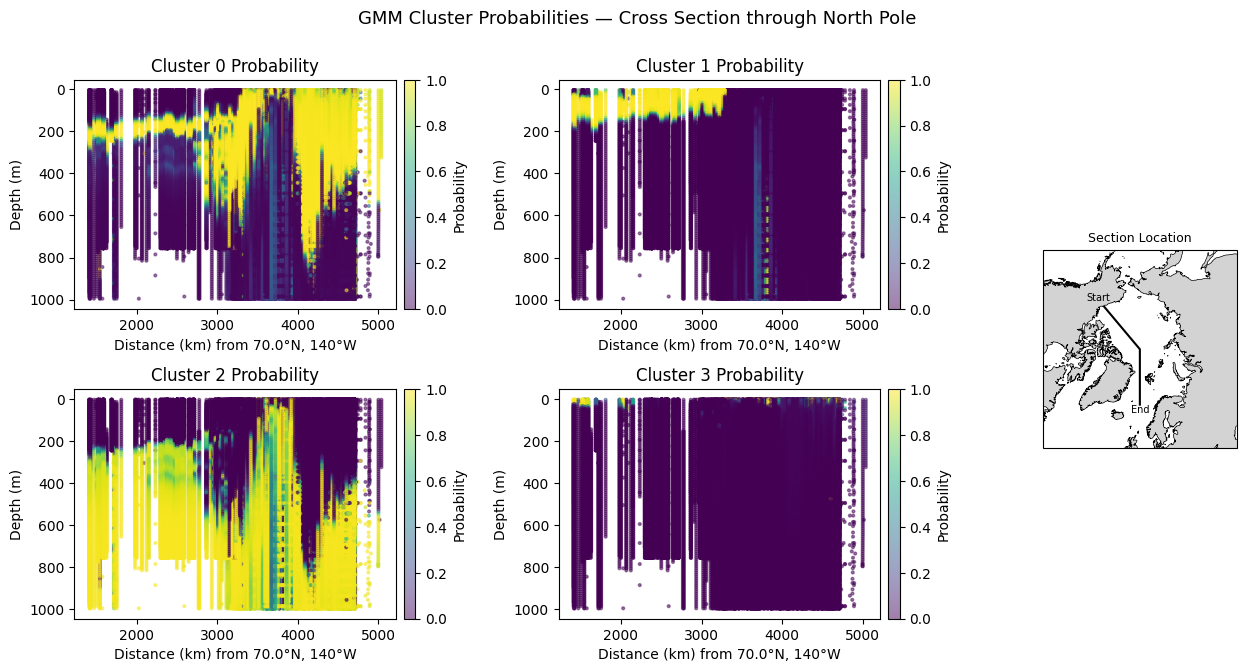

In [15]:
cross_sec_lon_prob(df_ST, -180, tol=0.5, start_lat=70.0, start_lon=-140)